# Baseline Solution - Monte Carlo Dropout

## This notebook documents the baseline solution for ADC 2023. 

## Overview
Our challenge is to provide a conditional probability distribution for each target (7 in total) given an observation from the Ariel Space Telescope. 

Depending on the information content of the observation and the associated observation noise (which is a function of the instrument and the planetary system), the resultant error bounds on each target and their joint conditional distribution will be different.

There are many directions you can take to tackle the problem on hand. We would like to get you started with our baseline solution. Inside this notebook you will find the setup for the baseline model, ways to compute the competition score and how to package the output into the competition format.

Spectroscopic data alone are usually informative enough to provide a reasonable estiamte on the targets. After all, the trough and peaks in the spectra encoded information about the relative abundance of each gaseous species (see [Yip et al.](https://iopscience.iop.org/article/10.3847/1538-3881/ac1744>) ). The supplementary information also helps to better constrain some of the phyiscal quantities (see our discussion [here](https://www.ariel-datachallenge.space/ML/documentation/about) if you want to learn about the underlying physics :) , but I shall leave that to you. 

The baseline solution trains a CNN to output a deterministic estimate for each atmospheric target. At inference time, the network is made to produce probabilistic output by activating the dropout layers in the network (Monte Carlo Dropout, [Gal et al. 2016](https://arxiv.org/abs/1506.02142)). 

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow import keras
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from helper import *
from preprocessing import *
from submit_format import to_competition_format
from posterior_utils import *
from MCDropout import MC_Convtrainer

### Fix seed


In [2]:
SEED=42

### Constants

In [3]:
RJUP = 69911000
MJUP = 1.898e27
RSOL = 696340000

## Read training data

In [4]:
training_path = 'data/TrainingData'

In [5]:
test_path = 'data/TestData'

In [6]:
training_GT_path = os.path.join(training_path, 'Ground Truth Package')

In [7]:
spectral_training_data = h5py.File(os.path.join(training_path,'SpectralData.hdf5'),"r")
aux_training_data = pd.read_csv(os.path.join(training_path,'AuxillaryTable.csv'))
soft_label_data = pd.read_csv(os.path.join(training_GT_path, 'FM_Parameter_Table.csv'))


## Extract Spectral data
Spectral data lives in a h5py format, which is useful for navigating different cases, but their format makes it difficult to bulk manage them. The helper function helps to transform the h5py file into a matrix of size N x 52 x 4
where N is the number of training examples, 52 is the number of wavelength channels and 4 is the observation data

In [9]:
spec_matrix = to_observed_matrix(spectral_training_data,aux_training_data)
print("spectral matrix shape:", spec_matrix.shape)

spectral matrix shape: (41423, 52, 4)


# Visualising a single spectrum

In [10]:
def visualise_spectrum(spectrum):
    fig = plt.figure(figsize=(10,6))
    ## multiple by 100 to turn it into percentage. 
    plt.errorbar(x=spectrum[:,0], y= spectrum[:,1]*100, yerr=spectrum[:,2]*100 )
    ## we tend to visualise it in log-scale
    plt.xscale('log')
    plt.xlabel('Wavelength (mircon)')
    plt.ylabel('Transit depth (%)')
    plt.show()

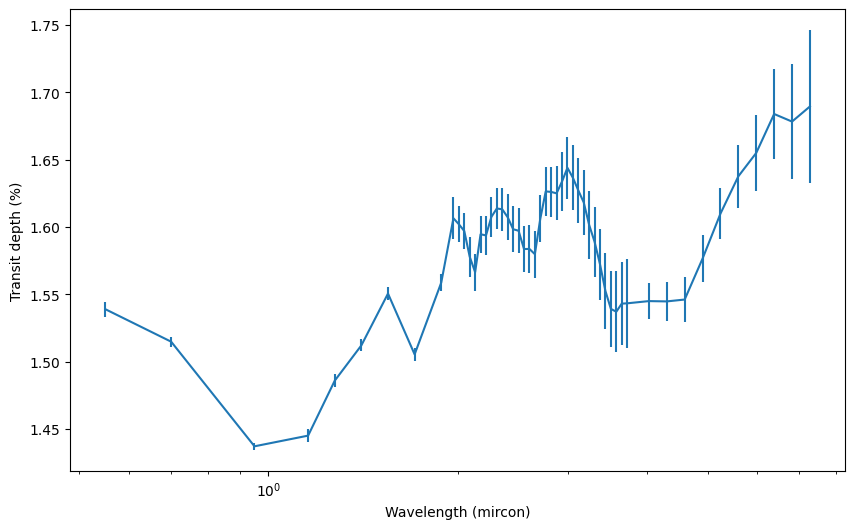

In [11]:
visualise_spectrum(spec_matrix[1])

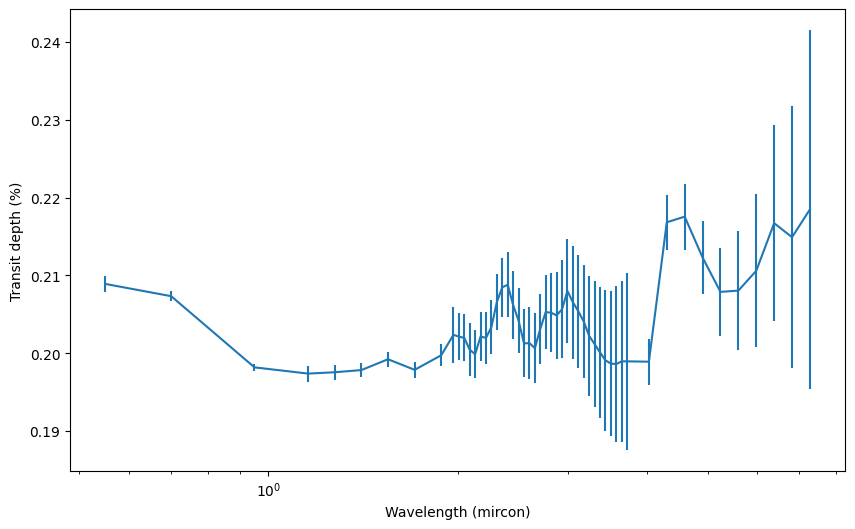

In [12]:
## lets look at another one
visualise_spectrum(spec_matrix[2])

it is immediately apparent that the average transit depth between two spectra can change for over an order of magnitude. The magnitude of the uncertainty can also change accordingly ( and is a function of the planetary system, brightness of the host star and instrument response function). 

## Pre-processing

### Settings

In [13]:
repeat = 5
threshold = 0.8 ## for train valid split.
N = 5000 # train on the first 5000 data instances, remember only some examples are labelled, others are unlabelled!

We can safely discard wlgrid (wavelength grid) and wlwidth (width of wavelength) since they are unchanged in the dataset

### Extract Spectrum

In [14]:
## extract the noise
noise = spec_matrix[:N,:,2]
## We will incorporate the noise profile into the observed spectrum by treating the noise as Gaussian noise.
spectra = spec_matrix[:N,:,1]
wl_channels = len(spec_matrix[0,:,0])
global_mean = np.mean(spectra)
global_std = np.std(spectra)


### Adding an additional feature - radius of the star 
Most of the time we know something about the planetary system before we even attempt to make an observation (we cant just point randomly with a multi-million euros instrument!). Some of these auxillary data may be useful for retrieval, here we are only using the radius of the star.

In [15]:
## add Rstar 
Rs = aux_training_data[['star_radius_m',]]
## we would prefer to use Rsol
Rs['star_radius'] = Rs['star_radius_m']/RSOL
Rs = Rs.drop(['star_radius_m'],axis=1)
Rs = Rs.iloc[:N, :]
mean_Rs = Rs.mean()
stdev_Rs = Rs.std()

/var/folders/wh/9tfsnwk52msftggvvzkn8gw00000gn/T/ipykernel_25863/776281745.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Rs['star_radius'] = Rs['star_radius_m']/RSOL


### Get targets

In [16]:
target_labels = ['planet_radius','planet_temp','log_H2O','log_CO2','log_CO','log_CH4','log_NH3']
targets = soft_label_data.iloc[:N][target_labels]
num_targets = targets.shape[1]
targets_mean = targets.mean()
targets_std = targets.std()

## Train/valid Split

In [17]:
ind = np.random.rand(len(spectra)) < threshold
training_spectra, training_Rs,training_targets, training_noise = spectra[ind],Rs[ind],targets[ind], noise[ind]
valid_spectra, valid_Rs, valid_targets = spectra[~ind],Rs[~ind],targets[~ind]


## Augment the dataset with noise (create multiple instances)
Observational noise from Ariel forms an important part of the challenge, any model must recognise that the observation are not absolute measurement and could vary (according to the uncertainty), as that will affect the uncertainty associated with our atmospheric targets. Here we try to incorporate these information by augmenting the data with the mean noise.

In [18]:
aug_spectra = augment_data_with_noise(training_spectra, training_noise, repeat)
aug_Rs = np.tile(training_Rs.values,(repeat,1))
aug_targets = np.tile(training_targets.values,(repeat,1))

### Standardise the data

### spectra

In [19]:
## standardise the input using global mean and stdev
std_aug_spectra = standardise(aug_spectra, global_mean, global_std)
std_aug_spectra = std_aug_spectra.reshape(-1, wl_channels)
std_valid_spectra = standardise(valid_spectra, global_mean, global_std)
std_valid_spectra = std_valid_spectra.reshape(-1, wl_channels)

### radius

In [20]:
## standardise
std_aug_Rs= standardise(aug_Rs, mean_Rs.values.reshape(1,-1), stdev_Rs.values.reshape(1,-1))
std_valid_Rs= standardise(valid_Rs, mean_Rs, stdev_Rs)


### target
We are asking the model to provide estimates for 6 atmospheric targets. In this example will be performing a supervised learning task. 

In [21]:
std_aug_targets = standardise(aug_targets, targets_mean.values.reshape(1,-1), targets_std.values.reshape(1,-1))
std_valid_targets = standardise(valid_targets, targets_mean, targets_std)

# Setup network


### hyperparameter settings


In [22]:
batch_size= 32
lr= 1e-3
epochs = 30
filters = [32,64,64]
dropout = 0.1
# number of examples to generate in evaluation time (5000 is max for this competition)
N_samples = 5000

We followed [Yip et al.](https://iopscience.iop.org/article/10.3847/1538-3881/ac1744>) and adopted a simple CNN structure and loss function. 


In [23]:
model = MC_Convtrainer(wl_channels,num_targets,dropout,filters)

### Compile model and Train!

In [25]:
## compile model and run
model.compile(
    optimizer=keras.optimizers.Adam(lr),
    loss='mse',)
model.fit([std_aug_spectra,std_aug_Rs], 
          std_aug_targets, 
          validation_data=([std_valid_spectra, std_valid_Rs],std_valid_targets),
          batch_size=batch_size, 
          epochs=epochs, 
          shuffle=False,)


Epoch 1/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2381 - val_loss: 0.2370
Epoch 2/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2341 - val_loss: 0.2415
Epoch 3/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2315 - val_loss: 0.2355
Epoch 4/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2294 - val_loss: 0.2386
Epoch 5/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2288 - val_loss: 0.2307
Epoch 6/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2250 - val_loss: 0.2365
Epoch 7/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2242 - val_loss: 0.2373
Epoch 8/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2217 - val_loss: 0.2412
Epoch 9/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2183 - val_loss: 0.2339
Epoch 10/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2178 - val_loss: 0.2374
Epoch 11/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2156 - val_loss: 0.2362
Epoch 12/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [26]:
# Evalute model with validation data

In [27]:
## select the corresponding GT for the validation data, and in the correct order.
index= np.arange(len(ind))
valid_index = index[~ind]

In [28]:
instances = N_samples
y_valid_distribution = np.zeros((instances, len(std_valid_spectra), num_targets ))
for i in tqdm(range(instances)):
    
    y_pred_valid = model([std_valid_spectra,std_valid_Rs],training=True)
    y_valid_distribution[i] += y_pred_valid

100%|██████████| 5000/5000 [01:43<00:00, 48.17it/s]


In [29]:
y_valid_distribution = y_valid_distribution.reshape(-1,num_targets)

In [30]:
y_pred_valid_org = transform_and_reshape(y_valid_distribution,targets_mean, targets_std,instances,N_testdata=len(std_valid_spectra))


In [31]:
tr1 = y_pred_valid_org
# weight takes into account the importance of each point in the tracedata. for now we just assume them to be equally weighted
weights1 = np.ones((tr1.shape[0],tr1.shape[1]))/np.sum(np.ones(tr1.shape[1]) )


In [32]:
# now load the ground truth 

In [33]:
trace_GT = h5py.File(os.path.join(training_GT_path, 'Tracedata.hdf5'),"r")

## posterior scores 
This score accounts for 80% of the final score and it is based on the entire dataset.

In [34]:
posterior_scores = []
bounds_matrix = default_prior_bounds()
for idx, pl_idx in enumerate(valid_index):
    tr_GT = trace_GT[f'Planet_train{pl_idx+1}']['tracedata'][()]
    weights_GT = trace_GT[f'Planet_train{pl_idx+1}']['weights'][()]
    ## there are cases without ground truth, we will skip over them for this baseline
    ## but every example in leaderboard and final evaluation set will have a complementary ground truth
    if np.isnan(tr_GT).sum() == 1:
        continue
    # compute posterior loss
    score = compute_posterior_loss(tr1[idx], weights1[idx], tr_GT, weights_GT, bounds_matrix)
    posterior_scores.append(score)
avg_posterior_score = np.mean(posterior_scores)    
    

In [35]:
print(avg_posterior_score)

339.42105263157896


## spectral scores (skipped)
Spectral scoring requires taurex and opacity linelists. Skipped for this baseline run — posterior score alone is sufficient for evaluation.

In [36]:
# Spectral scoring skipped (requires taurex + opacities)
# Using posterior score only for baseline evaluation
print(f"Posterior score: {avg_posterior_score:.4f}")

Posterior score: 339.4211


In [37]:
# skipped

In [38]:
# skipped

In [39]:
# skipped

In [40]:
# skipped

In [41]:
# skipped

In [42]:
# Using posterior-only score as final metric
print(f"Final baseline score (posterior only): {avg_posterior_score:.4f}")

Final baseline score (posterior only): 339.4211


# Generate prediction for leaderboard

### load leaderboard data

In [43]:
spec_test_data = h5py.File(os.path.join(test_path,'SpectralData.hdf5'),"r")
aux_test_data = pd.read_csv(os.path.join(test_path,'AuxillaryTable.csv'))

### same pre-processing as before...

In [44]:
test_spec_matrix = to_observed_matrix(spec_test_data,aux_test_data )

In [45]:
std_test_spectra = standardise(test_spec_matrix[:,:,1], global_mean, global_std)

In [47]:
test_Rs = aux_test_data[['star_radius_m']]
## we would prefer to use RSol 
test_Rs['star_radius'] = test_Rs['star_radius_m']/RSOL
test_Rs = test_Rs.drop(['star_radius_m'],axis=1)
std_test_Rs= standardise(test_Rs, mean_Rs, stdev_Rs)


/var/folders/wh/9tfsnwk52msftggvvzkn8gw00000gn/T/ipykernel_25863/4039943385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_Rs['star_radius'] = test_Rs['star_radius_m']/RSOL


## Predict and postprocess
We will sample 5000 times by activating dropout at inference phase. This is done explicitly via training = True. Note that in the competition, any sample size bigger than 5000 will NOT be accepted. However, the sample size must have a minimum of 1000 points to be a valid submission. 

In [48]:
tf.keras.utils.set_random_seed(SEED)

In [49]:
instances = N_samples
y_pred_distribution = np.zeros((instances, len(std_test_spectra), num_targets ))
for i in tqdm(range(instances)):
    
    y_pred = model([std_test_spectra,std_test_Rs],training=True)
    y_pred_distribution[i] += y_pred


100%|██████████| 5000/5000 [01:01<00:00, 81.03it/s]


In [50]:
y_pred_distribution = y_pred_distribution.reshape(-1,num_targets)

In [51]:
y_pred_test_org = transform_and_reshape(y_pred_distribution,targets_mean, targets_std,instances,N_testdata=len(std_test_spectra))

## Package output into desired format
We follow specific formats in the competition, to help make the process as painless as possible, we have included a few helper functions to make sure you have the right format in place for the submission. 

In [52]:
tracedata = y_pred_test_org
# weight takes into account the importance of each point in the tracedata. 
weight = np.ones((tracedata.shape[0],tracedata.shape[1]))/np.sum(np.ones(tracedata.shape[1]) )

submission = to_competition_format(tracedata, 
                                        weight, 
                                        name="submission.hdf5")

## check!

## Future work

There are different direction to take from here on, let us summarise the shortcomings of this model:
- The data preprocessing is quite simplistic and could have invested with more efforts.
- we have only used 5000 data points, instead of the full dataset
- we didnt train the model with results from the retrieval ( Tracedata.hdf5), which are the GT for this competition.
- The conditional distribution from MCDropout is very restricted and Gaussian-like
- So far we havent considered the atmospheric targets as a joint distribution
- We have only used stellar radius from the auxillary information
- We have not done any hyperparameter tuning 
- the train test split here is not clean, as in, we split the data after we have augmented the data, which results in information leakage to the validation data. There is no leakage to the test data though.